# KiwiCalc plotting stabilization demo

Run this notebook from the repository environment. It exercises the stabilized method contracts with visible plots and inline assertions. A failed contract stops execution immediately.

In [2]:
import inspect
import matplotlib.pyplot as plt
import numpy as np
import kiwicalc as kw

plt.close('all')
print('KiwiCalc loaded from:', inspect.getfile(kw.plot_multiple))
print('plot_multiple signature:', inspect.signature(kw.plot_multiple))
print('KiwiCalc plotting demo ready')

KiwiCalc loaded from: C:\Users\lenovo-pc\Desktop\data projects\kiwicalc\kiwicalc\plotting\plots.py
plot_multiple signature: (funcs, shape: 'Tuple[int, int]' = None, start: 'float' = -10, stop: 'float' = 10, step: 'float' = 0.01, ymin: 'float' = -10, ymax: 'float' = 10, title=None, show_axis=True, show=True, values=None, subplot_titles=None, sampling='fixed', tolerance=0.001, max_points=5000, max_depth=12)
KiwiCalc plotting demo ready


## 1. Standalone methods on caller-owned axes

Both helpers draw on the supplied axes and return their Matplotlib artists.

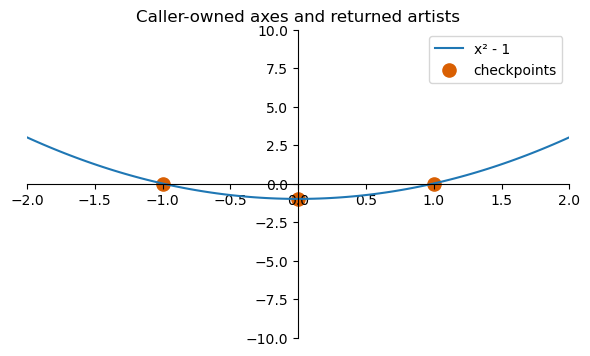

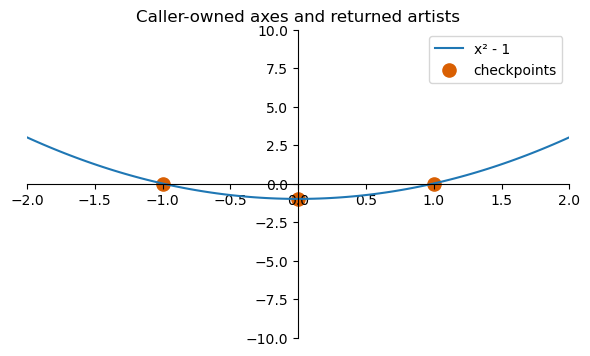

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
line = kw.plot_function('x^2 - 1', values=np.linspace(-2, 2, 101), fig=fig, ax=ax, show=False, label='x² - 1')
dots = kw.scatter_dots([-1, 0, 1], [0, -1, 0], fig=fig, ax=ax, show=False, color='#d95f02', label='checkpoints')
assert line.axes is ax and dots.axes is ax
ax.set_xlim(-2, 2)
ax.legend()
ax.set_title('Caller-owned axes and returned artists')
fig

## 2. Repeatable `Graph2D` rendering and scatter mode

The second render replaces the first. `scatter()` converts sampleable functions to points without accumulating old lines.

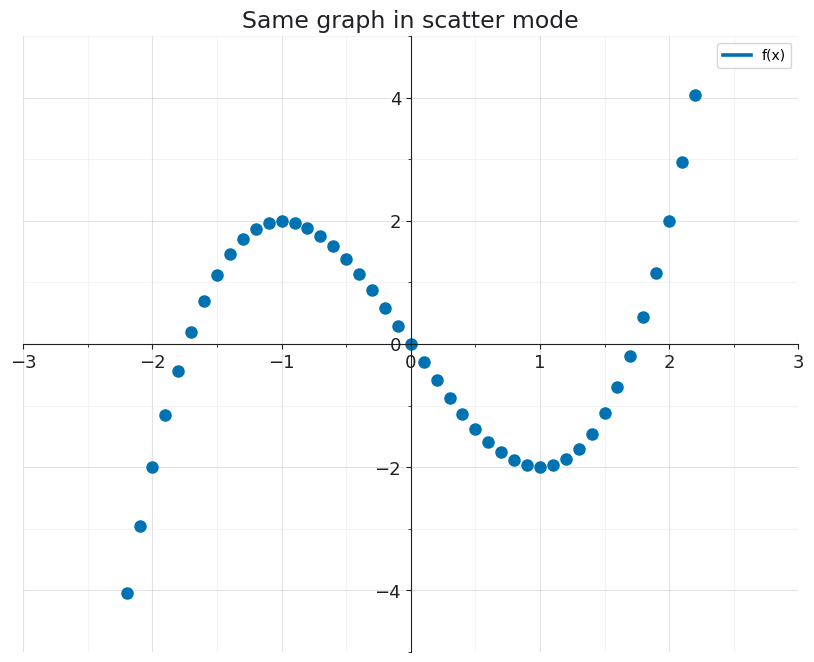

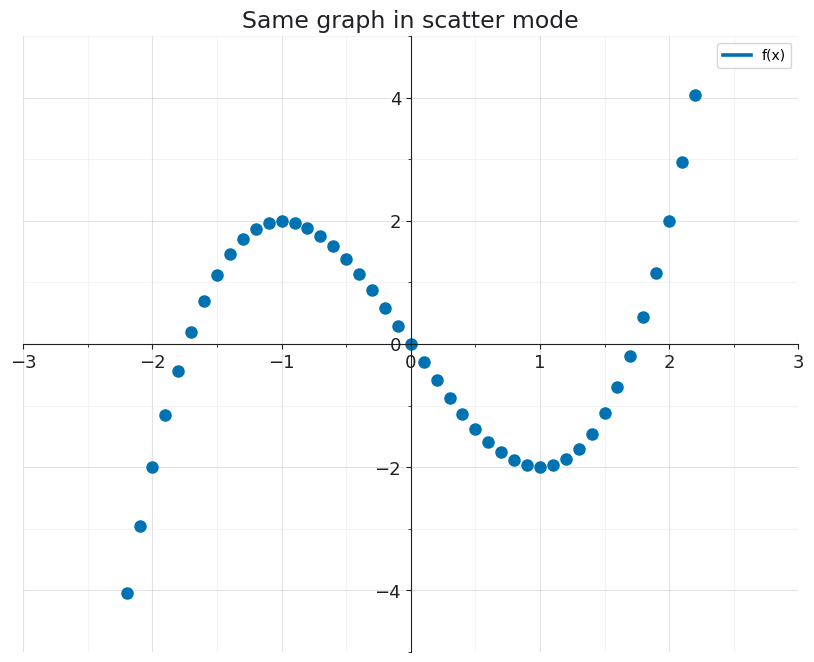

In [4]:
graph = kw.Graph2D().theme('classroom').add('x^3 - 3*x', label='f(x)')
graph.plot(values=np.linspace(-3, 3, 151), show=False, title='Initial line render', legend=True, xlim=(-3, 3), ylim=(-5, 5))
graph.scatter(values=np.linspace(-3, 3, 61), show=False, title='Same graph in scatter mode', legend=True, xlim=(-3, 3), ylim=(-5, 5))
assert len(graph.ax.lines) == 0
assert len(graph.ax.collections) == 1
graph.fig

## 3. Educational annotations and discontinuities

Roots and extrema are overlaid on a polynomial. The integral of `1/x` remains split at the undefined point instead of bridging the gap.

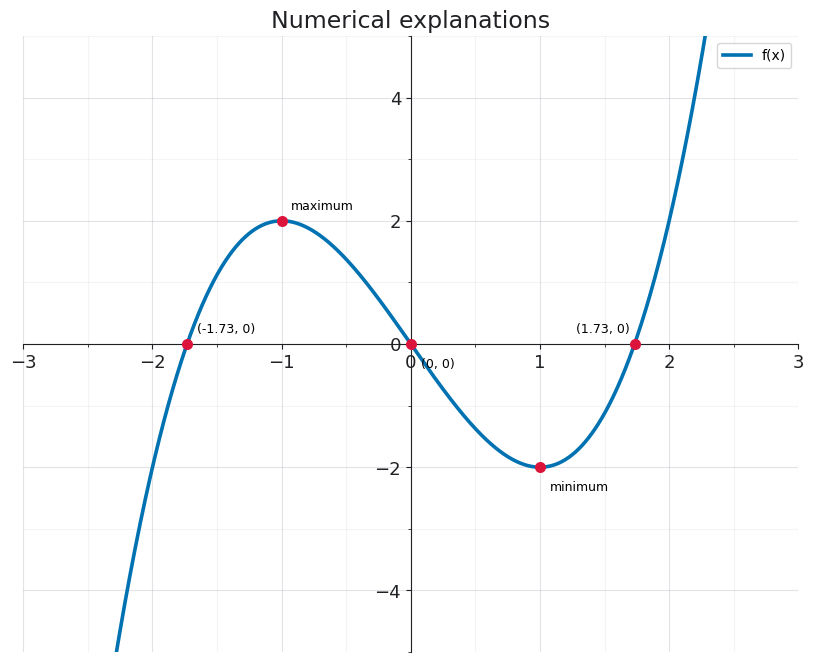

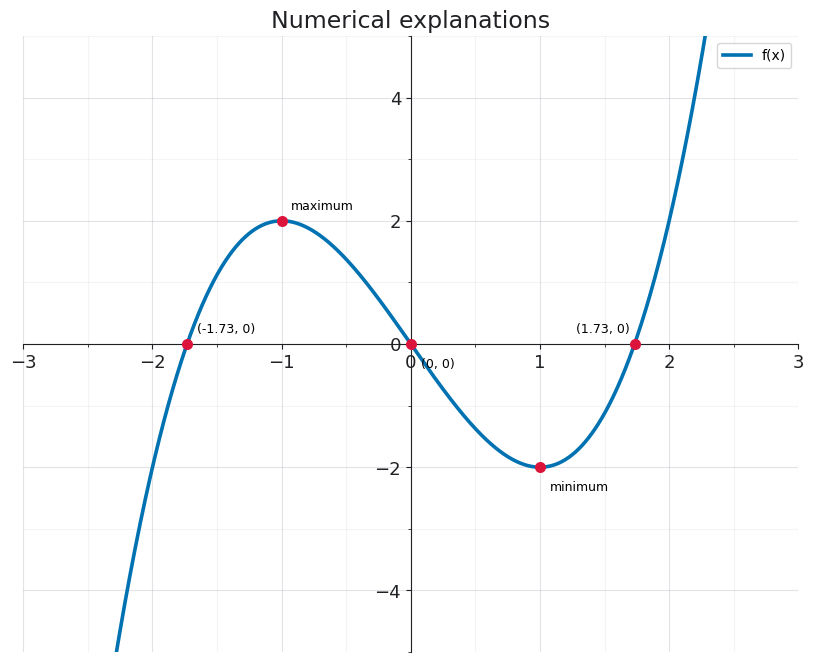

In [5]:
annotated = kw.Graph2D().theme('classroom').add('x^3 - 3*x', label='f(x)')
annotated.show_roots('x^3 - 3*x').show_extrema('x^3 - 3*x')
annotated.plot(values=np.linspace(-3, 3, 1201), show=False, title='Numerical explanations', legend=True, xlim=(-3, 3), ylim=(-5, 5))
annotated.fig

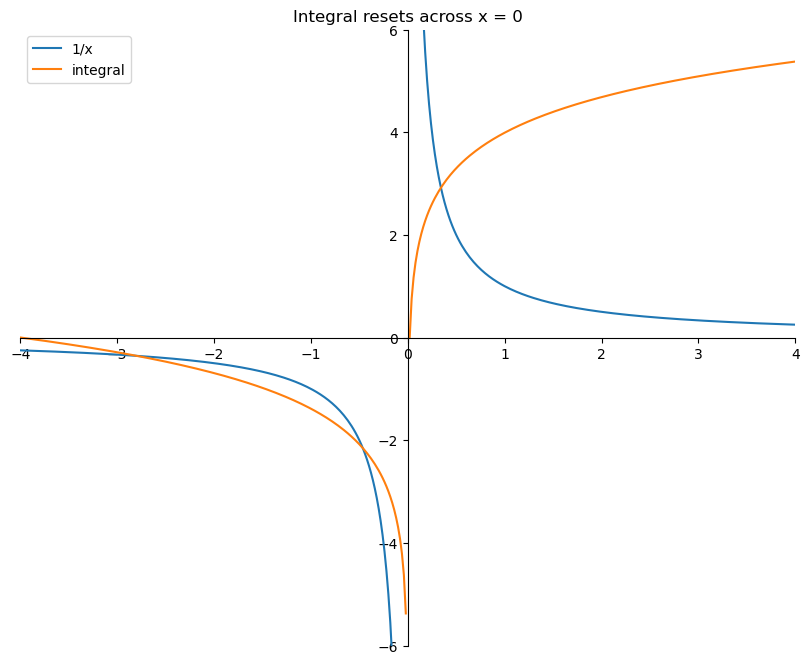

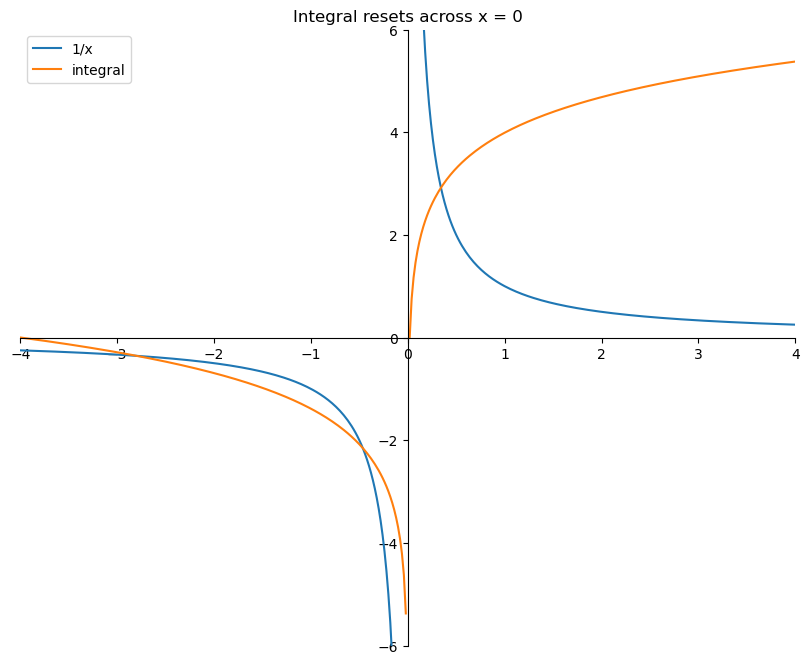

In [6]:
with np.errstate(divide='ignore', invalid='ignore'):
    discontinuous = kw.Graph2D().add(lambda x: 1 / x, label='1/x').show_integral(lambda x: 1 / x)
    artists = discontinuous.plot(values=np.linspace(-4, 4, 401), show=False, return_artists=True, title='Integral resets across x = 0', legend=True, xlim=(-4, 4), ylim=(-6, 6))
integral_y = np.asarray(artists[-1].get_ydata())
assert np.isnan(integral_y[200])
discontinuous.fig

## 4. Reliable subplot layouts

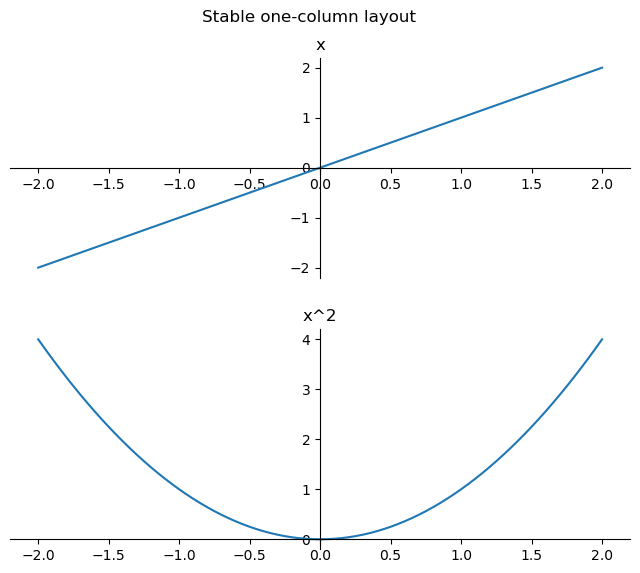

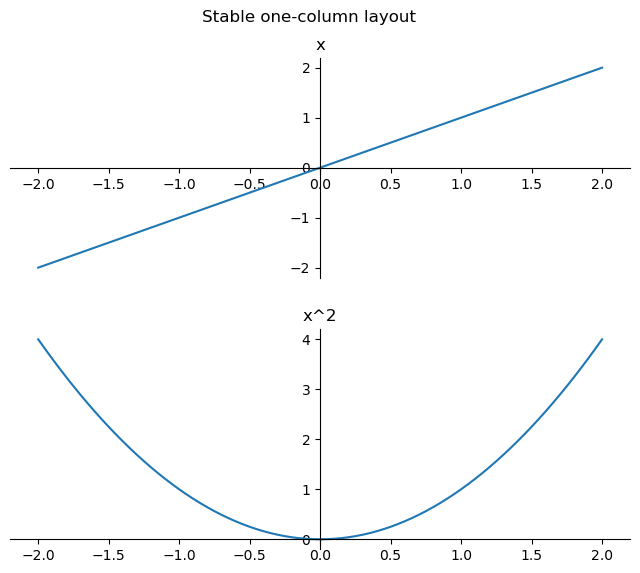

In [7]:
layout, axes = kw.plot_multiple(
    ['x', 'x^2'],
    shape=(2, 1), values=np.linspace(-2, 2, 81),
    title='Stable one-column layout', show=False,
)
assert axes.shape == (2, 1)
layout.set_size_inches(7, 6)
layout

## 5. Theme and axis configuration survive serialization

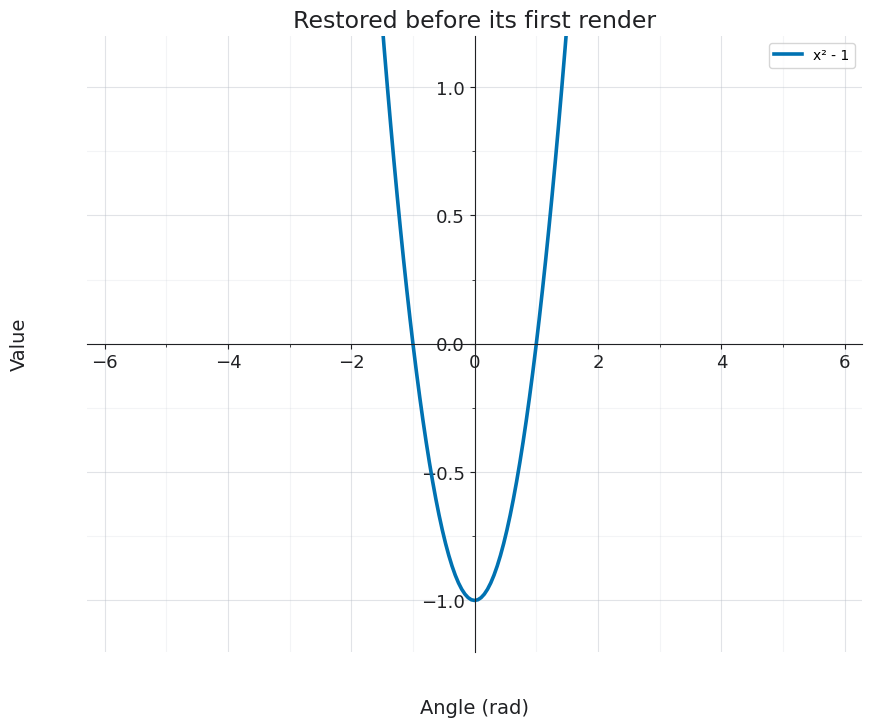

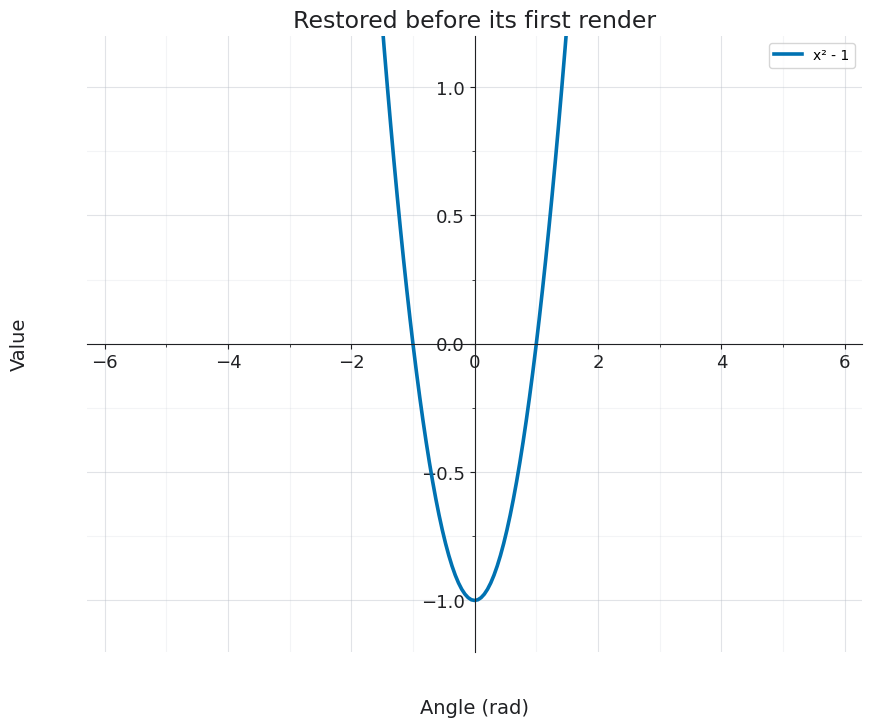

In [8]:
configured = kw.Graph2D().theme('classroom').configure_axes(xlabel='Angle', ylabel='Value', units=('rad', None), minor_ticks=True)
configured.add('x^2 - 1', label='x² - 1')
payload = configured.to_dict()
restored = kw.Graph.from_dict(payload)
restored.plot(values=np.linspace(-2*np.pi, 2*np.pi, 241), show=False, title='Restored before its first render', legend=True, xlim=(-2*np.pi, 2*np.pi), ylim=(-1.2, 1.2))
assert payload['version'] == 1
assert restored.ax.get_xlabel() == 'Angle (rad)'
restored.fig

## 6. Distribution plotting and explicit sample scatter

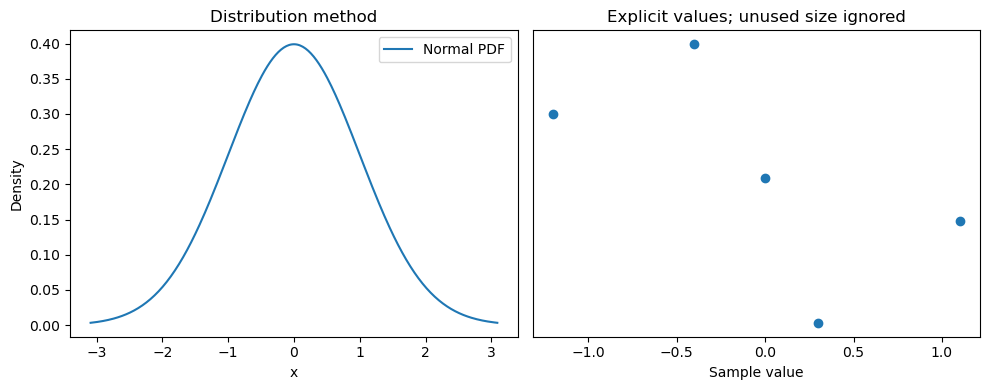

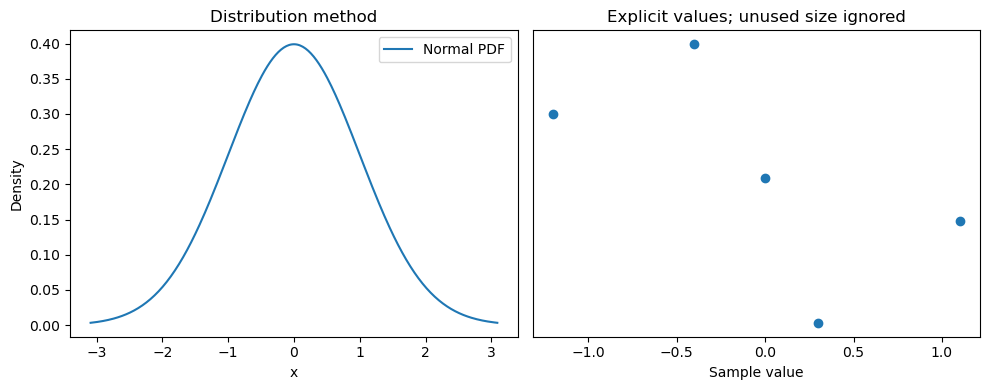

In [9]:
fig, (density_ax, sample_ax) = plt.subplots(1, 2, figsize=(10, 4))
normal = kw.Normal()
density = normal.plot(ax=density_ax, show=False, label='Normal PDF')
samples = normal.scatter(values=[-1.2, -0.4, 0.0, 0.3, 1.1], size=0, jitter=0.03, random_state=7, ax=sample_ax, show=False)
assert density.axes is density_ax and samples.axes is sample_ax
density_ax.legend()
density_ax.set_title('Distribution method')
sample_ax.set_title('Explicit values; unused size ignored')
fig.tight_layout()
fig

## 7. Lazy 3D graph and styled vector

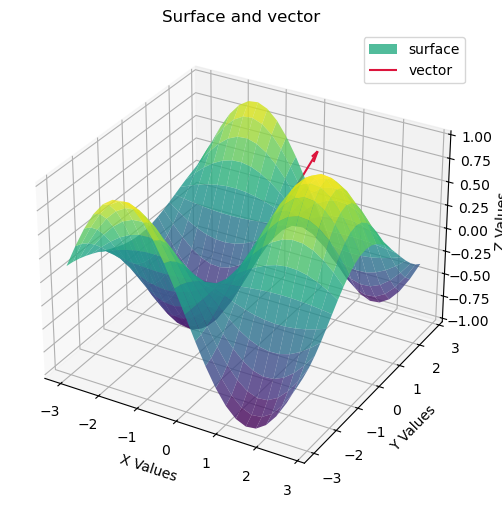

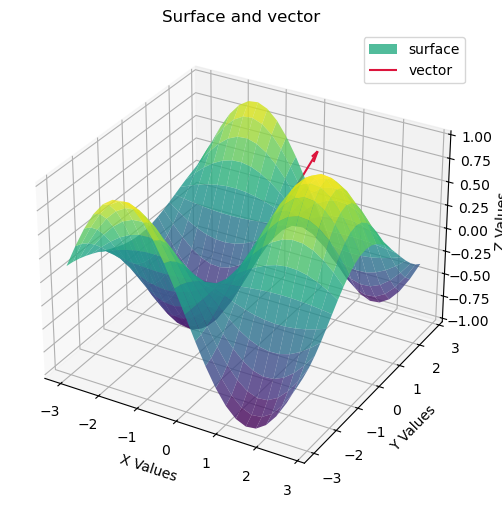

In [10]:
before = len(plt.get_fignums())
space = kw.Graph3D().add(lambda x, y: np.sin(x) * np.cos(y), label='surface', cmap='viridis', alpha=0.8)
assert len(plt.get_fignums()) == before
space.add(kw.Vector3D(1, 1, 1), label='vector', color='crimson')
space.plot(start=-3, stop=3, step=0.25, show=False, title='Surface and vector', legend=True)
assert len(space.artists) == 2
space.fig.set_size_inches(8, 6)
space.fig

## 8. Parameter interaction controller

`set_value()` uses the same update callback as the slider. In an interactive Matplotlib backend, the slider can also be dragged directly.

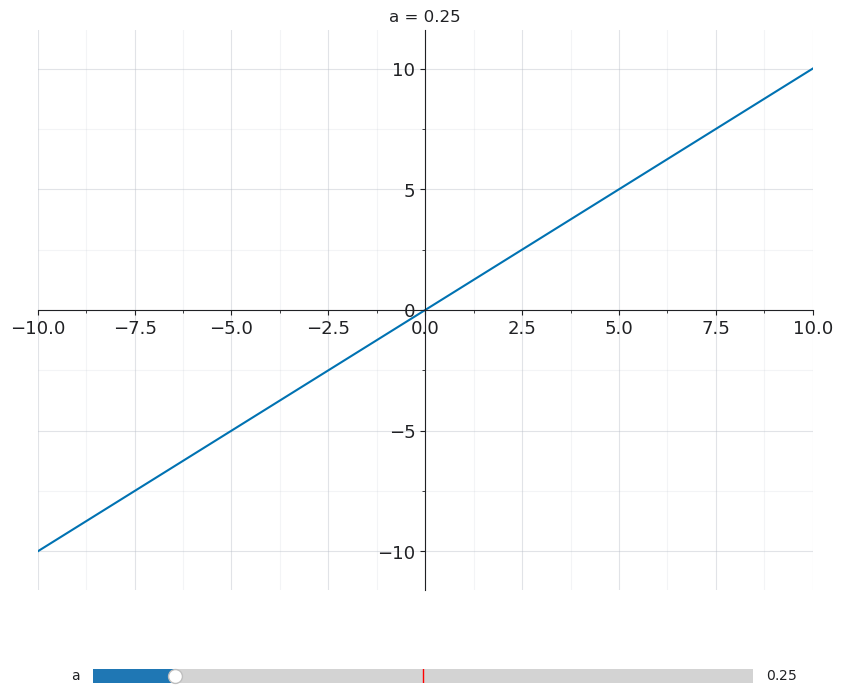

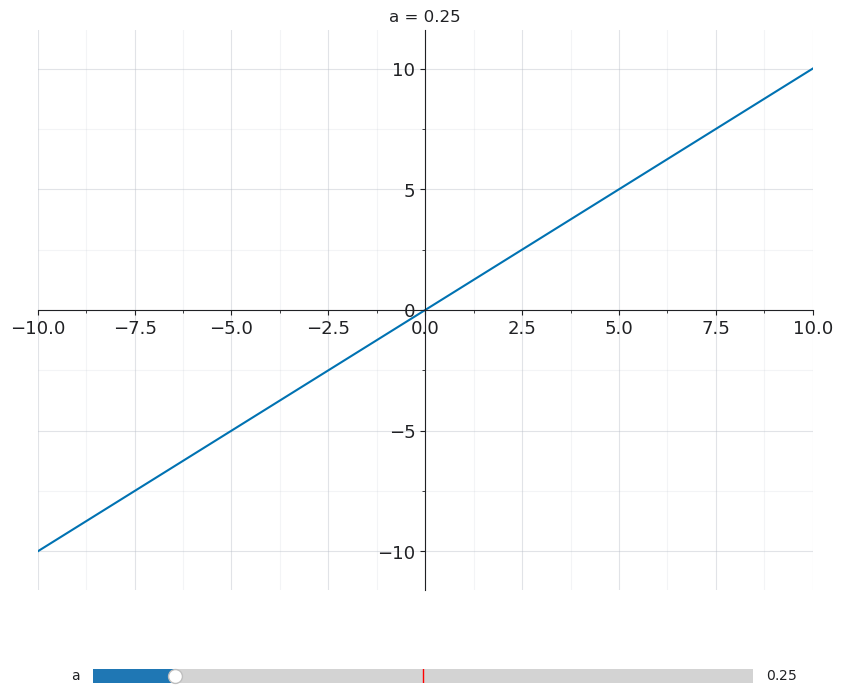

In [11]:
control = kw.Graph2D().theme('classroom').interact(
    lambda x, a: np.sin(2*np.pi*a) * x,
    (0, 2), initial=1, values=np.linspace(-10, 10, 201),
    title='a = {value:.2f}', show=False,
)
control.set_value(0.25)
assert control.value == 0.25
assert control.ax.get_ylim()[0] < -10 and control.ax.get_ylim()[1] > 10
control.fig

## 9. File-free export

The export API can return PNG bytes or SVG text directly, which is useful in notebooks, web services, and reports.

PNG: 87,271 bytes; SVG: 27,900 characters


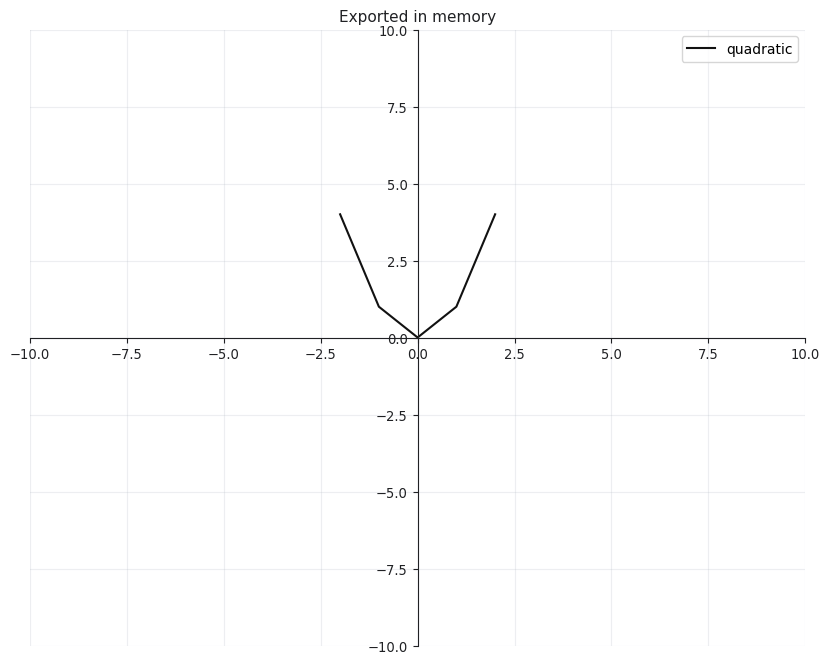

In [12]:
export_graph = kw.Graph2D().theme('publication').add('x^2', label='quadratic')
png_bytes = export_graph.to_bytes(plot_options={'values': [-2, -1, 0, 1, 2], 'title': 'Exported in memory', 'legend': True})
svg_text = export_graph.to_svg(render=False)
assert png_bytes.startswith(b'\x89PNG')
assert '<svg' in svg_text
print(f'PNG: {len(png_bytes):,} bytes; SVG: {len(svg_text):,} characters')

## Result

If execution reached this cell without an exception, every demonstrated plotting contract passed.